## E3

### Mision 0: aspectos basicos

Primero cargamos el archivo y revisamos su estructura general con `head()` y `describe()`.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) # netamente para ver todas las columnas del dataframe

df = pd.read_csv('data/E3_data.csv')
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,NaN,NaN
1,2008,1,2,21.46,NaN,NaN
2,2008,1,3,24.25,NaN,NaN
3,2008,1,4,29.04,NaN,NaN
4,2008,1,5,30.17,NaN,NaN


In [118]:
df.describe(include='all') # aqui le incluimos All. Sirve

,Year,Month,Day,O3,PM2.5,Environmental_risk
count,2984.000000,2984.000000,2984.000000,2878.000000,2725.000000,2656
unique,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,medio
freq,NaN,NaN,NaN,NaN,NaN,1605
mean,2011.592493,6.419236,15.715818,16.313767,28.814594,NaN
std,2.357040,3.487660,8.804066,7.995680,17.479388,NaN
min,2008.000000,1.000000,1.000000,1.000000,5.000000,NaN
25%,2010.000000,3.000000,8.000000,9.392500,16.170000,NaN
50%,2012.000000,6.000000,16.000000,16.960000,23.210000,NaN
75%,2014.000000,9.000000,23.000000,22.357500,37.210000,NaN


In [119]:
df.info()
print('\nvalores faltantes por columna:')
print(df.isna().sum())
print('\ncategorias de riesgo disponibles:')
print(df['Environmental_risk'].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2984 entries, 0 to 2983
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                2984 non-null   int64  
 1   Month               2984 non-null   int64  
 2   Day                 2984 non-null   int64  
 3   O3                  2878 non-null   float64
 4   PM2.5               2725 non-null   float64
 5   Environmental_risk  2656 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 140.0+ KB

valores faltantes por columna:
Year                    0
Month                   0
Day                     0
O3                    106
PM2.5                 259
Environmental_risk    328
dtype: int64

categorias de riesgo disponibles:
Environmental_risk
medio      1605
bajo        750
NaN         328
nulo        134
alto        106
extremo      61
Name: count, dtype: int64


Creamos tambien una columna de fecha, ya que sera necesaria para las visualizaciones y analisis temporales.

In [120]:
df['fecha'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,fecha
0,2008,1,1,29.63,NaN,NaN,2008-01-01
1,2008,1,2,21.46,NaN,NaN,2008-01-02
2,2008,1,3,24.25,NaN,NaN,2008-01-03
3,2008,1,4,29.04,NaN,NaN,2008-01-04
4,2008,1,5,30.17,NaN,NaN,2008-01-05


### Mision 1: imputacion de informacion faltante

Se crean dos DataFrame nuevos. En df_media se imputan los faltantes de O3 y PM2.5 con la media de cada columna. En df_drop se eliminan las filas que tienen faltantes en al menos una de estas dos columnas.

In [121]:
df_media = df.copy()

# 1er dataframe
df_media[['O3', 'PM2.5']] = df_media[['O3', 'PM2.5']].fillna(df_media[['O3', 'PM2.5']].mean())

# 2do dataframe
df_drop = df.dropna(subset=['O3', 'PM2.5']).copy()

print(f'datos originales: {df.shape}')
print(f'datos imputados con media: {df_media.shape}')
print(f'datos eliminando filas con faltantes: {df_drop.shape}')

datos originales: (2984, 7)
datos imputados con media: (2984, 7)
datos eliminando filas con faltantes: (2656, 7)


In [122]:
pd.DataFrame({
    'Original': df[['O3', 'PM2.5']].isna().sum(),
    'Imputado_media': df_media[['O3', 'PM2.5']].isna().sum(),
    'Sin_faltantes': df_drop[['O3', 'PM2.5']].isna().sum()
})
# netamente para ver que no haya nan

,Original,Imputado_media,Sin_faltantes
O3,106,0,0
PM2.5,259,0,0


### Mision 2: descripcion y comparacion

Definimos una funcion para calcular las metricas solicitadas de manera ordenada para ambos DataFrame.

In [123]:
def tabla_metricas(data, nombre):
    metricas = pd.DataFrame({
        'media': data[['O3', 'PM2.5']].mean(),
        'std': data[['O3', 'PM2.5']].std(),
        'max': data[['O3', 'PM2.5']].max(),
        'min': data[['O3', 'PM2.5']].min(),
        'curtosis': data[['O3', 'PM2.5']].kurt()
    })
    metricas['DataFrame'] = nombre
    metricas['correlacion_O3_PM25'] = data['O3'].corr(data['PM2.5'])
    metricas = metricas.reset_index().rename(columns={'index': 'contaminante'})
    return metricas.set_index(['DataFrame', 'contaminante'])

metricas_comparadas = pd.concat([
    tabla_metricas(df_media, 'Imputado_media'),
    tabla_metricas(df_drop, 'Sin_faltantes')
])

metricas_comparadas

media        std    max  min  curtosis  \
DataFrame      contaminante                                               
Imputado_media O3            16.313767   7.852333   56.3  1.0 -0.225798   
               PM2.5         28.814594  16.703334  126.2  5.0  2.508613   
Sin_faltantes  O3            15.961303   8.042349   56.3  1.0 -0.263541   
               PM2.5         28.986977  17.596844  126.2  5.0  1.958536   

                             correlacion_O3_PM25  
DataFrame      contaminante                       
Imputado_media O3                      -0.459890  
               PM2.5                   -0.459890  
Sin_faltantes  O3                      -0.478451  
               PM2.5                   -0.478451

Ahora se incorpora la variante individual. Se informa un mes y un contaminante y basta con reemplazar los valores de mes_asignado y contaminante_asignado.

In [124]:
mes_asignado = 8
contaminante_asignado = 'O3'  # 'O3' o 'PM2.5'

media_variante = pd.DataFrame({
    'DataFrame': ['Imputado_media', 'Sin_faltantes'],
    'mes': [mes_asignado, mes_asignado],
    'contaminante': [contaminante_asignado, contaminante_asignado],
    'media': [
        df_media.loc[df_media['Month'] == mes_asignado, contaminante_asignado].mean(),
        df_drop.loc[df_drop['Month'] == mes_asignado, contaminante_asignado].mean()
    ]
})

media_variante

,DataFrame,mes,contaminante,media
0,Imputado_media,8,O3,9.845323
1,Sin_faltantes,8,O3,9.629708


### Mision 3: visualizacion

Para ambos DataFrame se genera el histograma de PM2.5, el boxplot de O3 por mes y la evolucion anual promedio de O3 y PM2.5.

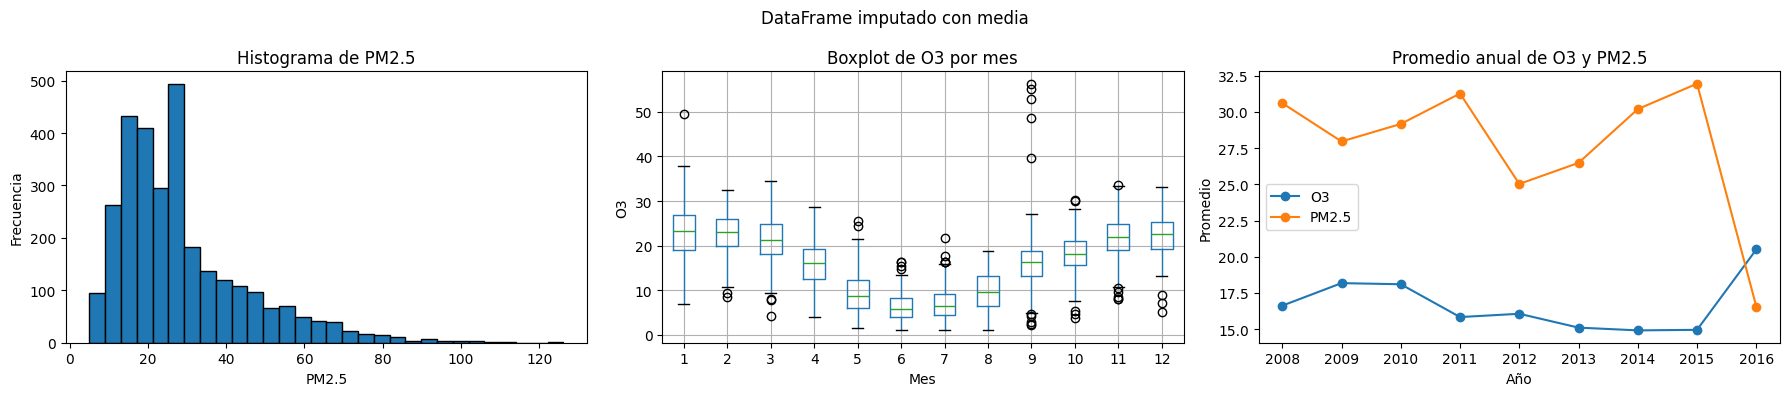

In [142]:
def visualizar_mision_3(data, nombre):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(data['PM2.5'], bins=30, edgecolor='black')
    axes[0].set_title('Histograma de PM2.5')
    axes[0].set_xlabel('PM2.5')
    axes[0].set_ylabel('Frecuencia')

    data.boxplot(column='O3', by='Month', ax=axes[1])
    axes[1].set_title('Boxplot de O3 por mes')

    # esto para eliminar el titulo automatico generado por pandas
    fig.suptitle(nombre)

    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('O3')

    promedio_anual = data.groupby('Year')[['O3', 'PM2.5']].mean()
    promedio_anual.plot(ax=axes[2], marker='o')
    axes[2].set_title('Promedio anual de O3 y PM2.5')
    axes[2].set_xlabel('Año')
    axes[2].set_ylabel('Promedio')

    plt.tight_layout()
    plt.show()

visualizar_mision_3(df_media, 'DataFrame imputado con media')

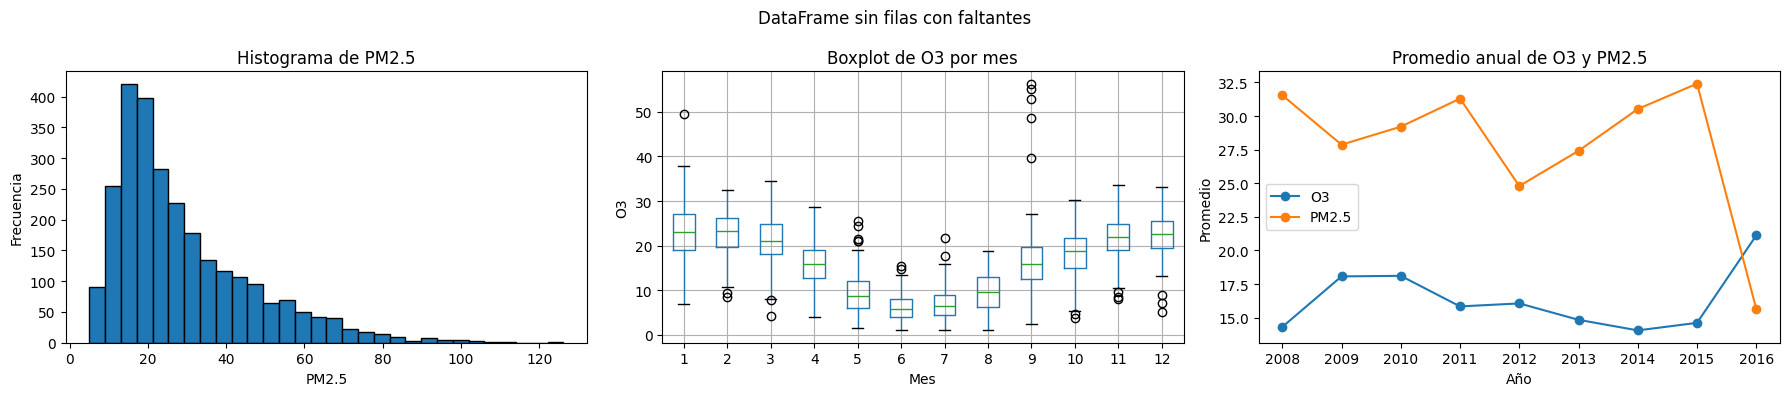

In [126]:
visualizar_mision_3(df_drop, 'DataFrame sin filas con faltantes')

### Mision 4: categorizacion

- Se propone un esquema basado en percentiles. 

- Para cada registro se calcula un puntaje de riesgo como el maximo percentil relativo entre O3 y PM2.5 

- La idea es que un registro sea considerado riesgoso si al menos uno de los dos contaminantes se encuentra alto respecto de la distribucion observada.

In [ ]:
niveles_riesgo = ['nulo', 'bajo', 'medio', 'alto', 'extremo']


def completar_riesgo(data):
    data = data.copy()
    percentiles = data[['O3', 'PM2.5']].rank(pct=True) # rankea por percentiles relativos de cada contaminante, dentro de sus propios datos.
    puntaje = percentiles.max(axis=1) # axis = 1 para comparar por fila, y tomar el maximo percentil relativo entre O3 y PM2.5 por cada fila.

    # O3 | PM2.5
    # 0.4 0.7
    # 0.3 0.2 

    riesgo_estimado = pd.cut( 
        puntaje,
        bins=[0, 0.20, 0.40, 0.70, 0.90, 1.00], # entre 0 y 0.2 es nulo, entre 0.2 y 0.4 es bajo, 
        # entre 0.4 y 0.7 es medio, entre 0.7 y 0.9 es alto, y entre 0.9 y 1 es extremo
        labels=niveles_riesgo,
        include_lowest=True # para incluir el limite inferior del primer bin, que es 0, y asi el primer bin sea [0, 0.2] en vez de (0, 0.2]
    ).astype('object')

    data['riesgo_estimado'] = riesgo_estimado
    data['Environmental_risk_completo'] = data['Environmental_risk'].fillna(data['riesgo_estimado'])
    return data


df_media_riesgo = completar_riesgo(df_media)
df_drop_riesgo = completar_riesgo(df_drop)


pd.DataFrame({
    'Imputado_media': df_media_riesgo['Environmental_risk_completo'].value_counts(),
    'Sin_faltantes': df_drop_riesgo['Environmental_risk_completo'].value_counts()
}).fillna(0).astype(int)

,Imputado_media,Sin_faltantes
Environmental_risk_completo,,
alto,196,106
bajo,750,750
extremo,95,61
medio,1809,1605
nulo,134,134


In [128]:
pd.DataFrame({
    'faltantes_originales_media': [df_media['Environmental_risk'].isna().sum()],
    'faltantes_completos_media': [df_media_riesgo['Environmental_risk_completo'].isna().sum()],
    'faltantes_originales_drop': [df_drop['Environmental_risk'].isna().sum()],
    'faltantes_completos_drop': [df_drop_riesgo['Environmental_risk_completo'].isna().sum()]
})

,faltantes_originales_media,faltantes_completos_media,faltantes_originales_drop,faltantes_completos_drop
0,328,0,0,0


- Al estar basado en percentiles, se adapta a la escala de cada DataFrame. 
- Una limitacion importante es claramente que no replica necesariamente el criterio original con que se asignaron las categorias

### Mision 5: analisis temporal avanzado

Creamos una columna con la estacion del anio a partir del mes. Luego calculamos las medias de O3 y PM2.5 por estacion y anio.

In [129]:
def obtener_estacion(mes):
    if mes in [12, 1, 2]:
        return 'verano'
    if mes in [3, 4, 5]:
        return 'otono'
    if mes in [6, 7, 8]:
        return 'invierno'
    return 'primavera'


df_temporal = df_media.copy()
df_temporal['estacion'] = df_temporal['Month'].apply(obtener_estacion)

medias_estacionales = (
    df_temporal
    .groupby(['Year', 'estacion'])[['O3', 'PM2.5']]
    .mean()
    .reset_index()
)

medias_estacionales.head()

,Year,estacion,O3,PM2.5
0,2008,invierno,7.083370,43.558370
1,2008,otono,15.798587,33.800085
2,2008,primavera,18.942747,19.676044
3,2008,verano,24.787692,25.184568
4,2009,invierno,10.351604,41.451898


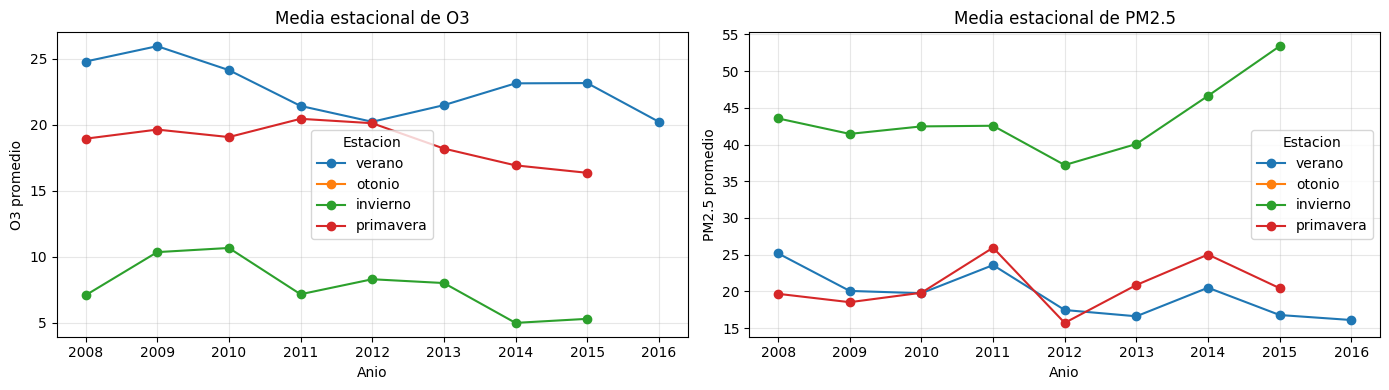

In [130]:
orden_estaciones = ['verano', 'otonio', 'invierno', 'primavera']

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for estacion in orden_estaciones:
    subset = medias_estacionales[medias_estacionales['estacion'] == estacion]
    axes[0].plot(subset['Year'], subset['O3'], marker='o', label=estacion)
    axes[1].plot(subset['Year'], subset['PM2.5'], marker='o', label=estacion)

axes[0].set_title('Media estacional de O3')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('O3 promedio')

axes[1].set_title('Media estacional de PM2.5')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('PM2.5 promedio')

for ax in axes:
    ax.legend(title='Estacion')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La separacion por estacion permite observar si los contaminantes se concentran en ciertos periodos del año, util porque la contaminacion atmosferica no suele variar solo por tendencia anual, sino tambien por condiciones meteorologicas y ciclos estacionales.

### Mision 6: deteccion de anomalias

Se implementa el metodo del rango intercuartilico (IQR). Un valor se considera atipico si esta por debajo de Q1 - 1.5 * IQR o por encima de Q3 + 1.5 * IQR.

In [131]:
def mascara_iqr(data, columna):
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return (data[columna] < limite_inferior) | (data[columna] > limite_superior) # el | es "o" lógico.


df_anomalias_base = df_temporal.copy()
df_anomalias_base['anomalia_O3'] = mascara_iqr(df_anomalias_base, 'O3')
df_anomalias_base['anomalia_PM25'] = mascara_iqr(df_anomalias_base, 'PM2.5')
df_anomalias_base['anomalia'] = df_anomalias_base['anomalia_O3'] | df_anomalias_base['anomalia_PM25']

df_atipicos = df_anomalias_base[df_anomalias_base['anomalia']].copy()

df_atipicos.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,fecha,estacion,anomalia_O3,anomalia_PM25,anomalia
130,2008,5,10,15.33,69.40,medio,2008-05-10,otono,False,True,True
131,2008,5,11,18.12,91.08,medio,2008-05-11,otono,False,True,True
135,2008,5,15,12.08,81.66,medio,2008-05-15,otono,False,True,True
136,2008,5,16,16.25,72.38,medio,2008-05-16,otono,False,True,True
150,2008,5,30,5.00,63.21,medio,2008-05-30,otono,False,True,True


In [132]:
print(f'cantidad de registros atipicos: {len(df_atipicos)}')

resumen_anomalias = pd.DataFrame({
    'por_anio': df_atipicos['Year'].value_counts().sort_index(),
})
resumen_anomalias

cantidad de registros atipicos: 154


,por_anio
Year,
2008,24
2009,12
2010,14
2011,18
2012,9
2013,5
2014,24
2015,48


In [133]:
resultado = pd.DataFrame({
    'anomalias_por_estacion': df_atipicos['estacion'].value_counts(),
    'total_por_estacion': df_anomalias_base['estacion'].value_counts()
})

resultado = resultado.fillna(0)

resultado['proporcion'] = (
    resultado['anomalias_por_estacion'] / resultado['total_por_estacion']
)

resultado = resultado.sort_values('proporcion', ascending=False)

resultado

,anomalias_por_estacion,total_por_estacion,proporcion
estacion,,,
invierno,112,736,0.152174
otono,34,738,0.046070
primavera,5,728,0.006868
verano,3,782,0.003836


Con las tablas anteriores se puede revisar si las anomalias se concentran en ciertos anios o estaciones. 

Si una estacion tiene una proporcion alta de atipicos, podria ser que existan eventos ambientales recurrentes o condiciones de medicion particulares en ese periodo.

### Mision 7: transformacion y enriquecimiento de datos

Se crean nuevas variables para enriquecer la interpretacion del conjunto: razon entre contaminantes, dias extremos consecutivos, tipo de dia, tabla dinamica y medias moviles de siete dias.

In [134]:
df_enriquecido = df_media_riesgo.copy().sort_values('fecha').reset_index(drop=True)

df_enriquecido['ratio_O3_PM25'] = df_enriquecido['O3'] / df_enriquecido['PM2.5']

p95_o3 = df_enriquecido['O3'].quantile(0.95)
p95_pm25 = df_enriquecido['PM2.5'].quantile(0.95)

df_enriquecido['extremo_p95'] = (df_enriquecido['O3'] > p95_o3) | (df_enriquecido['PM2.5'] > p95_pm25)

df_enriquecido['fecha_anterior'] = df_enriquecido['fecha'].shift(1)
df_enriquecido['extremo_anterior'] = df_enriquecido['extremo_p95'].shift(1, fill_value=False) # shift desplaza los valores (una) fila hacia abajo para poder acceder al valor anterior.
# el fill value False hace que en vez de que el primer valor de la columna 'extremo_anterior' sea NaN, sea False, lo cual es útil para la lógica que sigue
df_enriquecido['dia_consecutivo'] = df_enriquecido['fecha'].diff().dt.days.eq(1) # diff calcula la diferencia entre fechas consecutivas, y dt.days extrae la cantidad de dias de esa diferencia. 
# Luego eq(1) compara si esa cantidad de dias es igual a 1, devolviendo True o False.

df_enriquecido['extremo_consecutivo'] = (
    df_enriquecido['extremo_p95']
    & df_enriquecido['extremo_anterior']
    & df_enriquecido['dia_consecutivo']
)

df_enriquecido[['fecha', 'O3', 'PM2.5', 'ratio_O3_PM25', 'extremo_p95', 'extremo_consecutivo']].head()

,fecha,O3,PM2.5,ratio_O3_PM25,extremo_p95,extremo_consecutivo
0,2008-01-01,29.63,28.814594,1.028298,True,False
1,2008-01-02,21.46,28.814594,0.744761,False,False
2,2008-01-03,24.25,28.814594,0.841587,False,False
3,2008-01-04,29.04,28.814594,1.007823,True,False
4,2008-01-05,30.17,28.814594,1.047039,True,True


Básicamente marca un día como extremo si O3 o PM2.5 están por encima de su P95. Después, marca si ese día extremo viene inmediatamente después de otro día extremo

In [135]:
dias_semana = {
    0: 'lunes',
    1: 'martes',
    2: 'miercoles',
    3: 'jueves',
    4: 'viernes',
    5: 'sabado',
    6: 'domingo'
}

df_enriquecido['dia_semana'] = df_enriquecido['fecha'].dt.dayofweek.map(dias_semana) # mapeamos los numeros de dia de la semana (0-6) a sus nombres correspondientes 
# usando el diccionario dias_semana
df_enriquecido['tipo_dia'] = np.where(df_enriquecido['fecha'].dt.dayofweek >= 5, 'fin_de_semana', 'dia_laboral') # si es que es mayor o igual a 5 (sabado o domingo), entonces es fin de semana, sino es dia laboral

df_enriquecido[['fecha', 'dia_semana', 'tipo_dia']].head()

,fecha,dia_semana,tipo_dia
0,2008-01-01,martes,dia_laboral
1,2008-01-02,miercoles,dia_laboral
2,2008-01-03,jueves,dia_laboral
3,2008-01-04,viernes,dia_laboral
4,2008-01-05,sabado,fin_de_semana


In [136]:
tabla_dinamica_riesgo = pd.pivot_table(
    df_enriquecido,
    values=['O3', 'PM2.5'],
    index='Month',
    columns='Environmental_risk_completo',
    aggfunc='mean'
)

tabla_dinamica_riesgo

O3                                   \
Environmental_risk_completo       alto       bajo    extremo      medio   
Month                                                                     
1                            27.784793        NaN  29.098333  17.523236   
2                            23.124444  20.472920  28.672727  23.765025   
3                            23.482304  18.042683  28.167500  22.629158   
4                            22.365471  13.508889  26.210000  15.967133   
5                            16.313767   7.564000        NaN   9.589429   
6                                  NaN   8.238235  16.313767   6.142945   
7                            16.313767  10.913889  16.313767   6.578920   
8                                  NaN  10.574146        NaN   9.700967   
9                            16.313767  15.554167  47.975000  16.239681   
10                           22.747500  16.772712  26.700000  19.169084   
11                           23.507500  20.084298  28.631500  22.197630   
12                           23.822222  20.290000  29.071111  23.211222   

                                           PM2.5                        \
Environmental_risk_completo      nulo       alto       bajo    extremo   
Month                                                                    
1                            19.30694  23.575115        NaN  28.814594   
2                                 NaN  28.814594  14.361327  18.624926   
3                                 NaN  29.542774  14.728171  27.351520   
4                                 NaN  29.662770  15.458889  28.814594   
5                                 NaN  38.040000  13.992667        NaN   
6                                 NaN        NaN  13.955882  52.890000   
7                                 NaN  36.080000  12.557222  53.190000   
8                                 NaN        NaN  14.184634        NaN   
9                                 NaN  40.486667  13.349028  13.500000   
10                                NaN  28.814594  14.097203  28.814594   
11                                NaN  28.814594  12.943884  17.726419   
12                                NaN  28.814594  14.160952  17.791622   

                                                   
Environmental_risk_completo      medio       nulo  
Month                                              
1                            28.814594  14.959851  
2                            25.754523        NaN  
3                            26.767313        NaN  
4                            31.563584        NaN  
5                            44.721389        NaN  
6                            51.264334        NaN  
7                            49.580128        NaN  
8                            39.056923        NaN  
9                            28.242094        NaN  
10                           24.599405        NaN  
11                           25.845328        NaN  
12                           25.077744        NaN

In [ ]:
df_enriquecido['O3_media_movil_7d'] = (
    df_enriquecido
    .groupby('Year')['O3'] # divide los datos en grupos, se agrupa por año
    .transform(lambda s: s.rolling(window=7, min_periods=1).mean()) # y transform() hace que el resultado final mantenga el mismo número de filas y el mismo 
    # índice que el df original
    # rolling le indica a pandas que calcule la media movil en una ventana de 7 (dias en este caso) y el min periods hace que lo haga incluso si hay menos de 7
)

df_enriquecido['PM25_media_movil_7d'] = (
    df_enriquecido
    .groupby('Year')['PM2.5']
    .transform(lambda s: s.rolling(window=7, min_periods=1).mean())
)

df_enriquecido[['fecha', 'O3', 'O3_media_movil_7d', 'PM2.5', 'PM25_media_movil_7d']].head(10)

,fecha,O3,O3_media_movil_7d,PM2.5,PM25_media_movil_7d
0,2008-01-01,29.63,29.630000,28.814594,28.814594
1,2008-01-02,21.46,25.545000,28.814594,28.814594
2,2008-01-03,24.25,25.113333,28.814594,28.814594
3,2008-01-04,29.04,26.095000,28.814594,28.814594
4,2008-01-05,30.17,26.910000,28.814594,28.814594
5,2008-01-06,29.50,27.341667,28.814594,28.814594
6,2008-01-07,26.79,27.262857,28.814594,28.814594
7,2008-01-08,25.29,26.642857,28.814594,28.814594
8,2008-01-09,14.62,25.665714,28.814594,28.814594
9,2008-01-10,18.17,24.797143,28.814594,28.814594


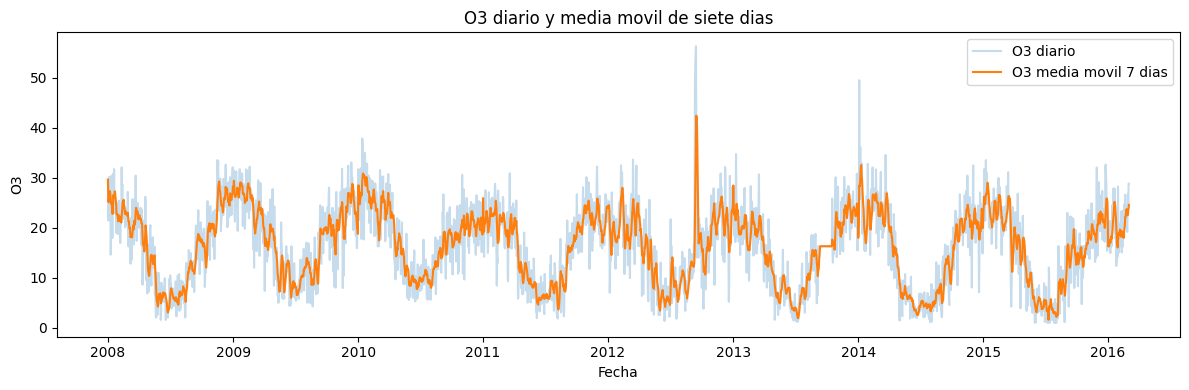

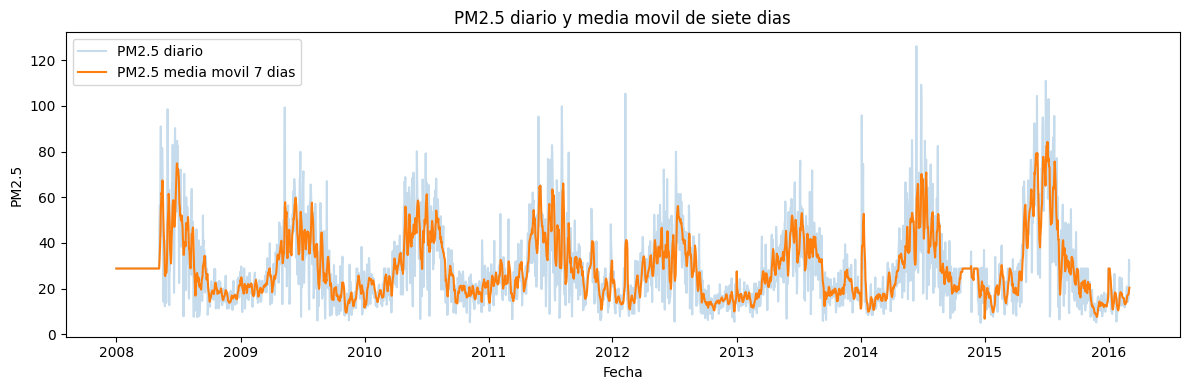

In [138]:
plt.figure(figsize=(12, 4))
plt.plot(df_enriquecido['fecha'], df_enriquecido['O3'], alpha=0.25, label='O3 diario')
plt.plot(df_enriquecido['fecha'], df_enriquecido['O3_media_movil_7d'], label='O3 media movil 7 dias')
plt.title('O3 diario y media movil de siete dias')
plt.xlabel('Fecha')
plt.ylabel('O3')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_enriquecido['fecha'], df_enriquecido['PM2.5'], alpha=0.25, label='PM2.5 diario')
plt.plot(df_enriquecido['fecha'], df_enriquecido['PM25_media_movil_7d'], label='PM2.5 media movil 7 dias')
plt.title('PM2.5 diario y media movil de siete dias')
plt.xlabel('Fecha')
plt.ylabel('PM2.5')
plt.legend()
plt.tight_layout()
plt.show()

In [139]:
resumen_enriquecimiento = pd.DataFrame({
    'registros': [len(df_enriquecido)],
    'dias_extremos_p95': [df_enriquecido['extremo_p95'].sum()],
    'dias_extremos_consecutivos': [df_enriquecido['extremo_consecutivo'].sum()],
    'ratio_promedio_O3_PM25': [df_enriquecido['ratio_O3_PM25'].mean()],
    'ratio_mediano_O3_PM25': [df_enriquecido['ratio_O3_PM25'].median()]
})

resumen_enriquecimiento

,registros,dias_extremos_p95,dias_extremos_consecutivos,ratio_promedio_O3_PM25,ratio_mediano_O3_PM25
0,2984,297,132,0.8197,0.757792


Estas transformaciones agregan informacion que no estaba disponible de forma directa. 

- El ratio O3 / PM2.5 compara la importancia relativa de ambos contaminantes en cada dia. 

- La marca de extremos sobre el percentil 95 ayuda a detectar episodios severos, y la variable de dias consecutivos distingue eventos aislados de periodos persistentes. 

- El dia de la semana permite evaluar posibles diferencias entre dias laborales y fines de semana. 

Así, la tabla dinamica resume la relacion entre mes y riesgo ambiental, mientras que las medias moviles suavizan la variabilidad diaria y hacen mas visibles las tendencias temporales.